In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [29]:
# load the data
resultats_1 = pd.read_excel("./data/2022_resultats_circonscription_tour_1.xlsx")
resultats_2 = pd.read_excel("./data/2022_resultats_circonscription_tour_2.xlsx")
candidats_1 = pd.read_excel("./data/candidatures_tour_1.xlsx")
candidats_2 = pd.read_excel("./data/2022_candidatures_tour_2.xlsx")

political_views = pd.read_csv("./data/1999-2024_CHES_dataset_means.csv")

In [30]:
print(resultats_1.head())

  Code département Libellé du département  Code circonscription législative  \
0               01                    Ain                                 1   
1               01                    Ain                                 2   
2               01                    Ain                                 3   
3               01                    Ain                                 4   
4               01                    Ain                                 5   

  Libellé de la circonscription Etat saisie  Inscrits  Abstentions  % Abs/Ins  \
0          1ère circonscription     Complet     86187        43652      50.65   
1          2ème circonscription     Complet     99953        50270      50.29   
2          3ème circonscription     Complet     82204        45946      55.89   
3          4ème circonscription     Complet     94897        49258      51.91   
4          5ème circonscription     Complet     77456        40382      52.14   

   Votants  % Vot/Ins  ...  Unnamed: 2

In [31]:
# normalize the data
resultats_1["Code circonscription législative"] = resultats_1["Code département"].astype(str).str.zfill(2) + resultats_1["Code circonscription législative"].astype(str).str.zfill(2)
resultats_2["Code circonscription législative"] = resultats_2["Code département"].astype(str).str.zfill(2) + resultats_2["Code circonscription législative"].astype(str).str.zfill(2)

candidats_2["Code circonscription"] = candidats_2["Code du département"].astype(str).str.zfill(2) + candidats_2["Code circonscription"].astype(str).str.zfill(2)
candidats_1["Code circonscription"] = candidats_1["Code circonscription"].astype(str).str.zfill(4)
candidats_2["Code circonscription"] = candidats_2["Code circonscription"].astype(str).str.zfill(4)

# remove outside french metropole
outre_mer_codes = ['ZA', 'ZM', 'ZD', 'ZB','ZC', 'ZN', 'ZS', 'ZX', 'ZW', 'ZP', 'ZZ', 971, 972, 973, 974, 975, 976, 986, 987, 988]

# Separate the mainland and overseas territories
resultats_1 = resultats_1[~resultats_1['Code département'].isin(outre_mer_codes)]
resultats_2 = resultats_2[~resultats_2['Code département'].isin(outre_mer_codes)]

# get only the politicals view for France in 2024
political_views = political_views[political_views["country"] == 6]
print(political_views["electionyear"].unique())
political_views = political_views[political_views["electionyear"] == 2024]

# keep only the columns without NaN values
political_views = political_views.dropna(axis=1)

[1997 2002 2007 2012 2017 2024]


In [32]:
print(len(resultats_2["Code circonscription législative"].unique()))

534


In [33]:
print(political_views.columns)

Index(['year', 'country', 'eastwest', 'eumember', 'party_id', 'party', 'vote',
       'seat', 'electionyear', 'epvote', 'family', 'lrgen', 'lrecon',
       'lrecon_salience', 'lrecon_dissent', 'lrecon_blur', 'galtan',
       'galtan_salience', 'galtan_dissent', 'galtan_blur', 'eu_position',
       'eu_salience', 'eu_dissent', 'eu_blur', 'spendvtax', 'deregulation',
       'redistribution', 'redist_salience', 'civlib_laworder', 'womens_rights',
       'lgbtq_rights', 'samesex_marriage', 'religious_principles',
       'immigrate_policy', 'immigrate_salience', 'immigrate_dissent',
       'multiculturalism', 'multicult_salience', 'nationalism',
       'ethnic_minorities', 'urban_rural', 'environment', 'enviro_salience',
       'climate_change', 'climate_change_salience', 'protectionism', 'regions',
       'eu_intmark', 'eu_foreign', 'eu_russia', 'anti_islam_rhetoric',
       'people_vs_elite', 'antielite_salience', 'corrupt_salience',
       'executive_power', 'judicial_independence', 'che

In [34]:
def get_best_candidate(resultats_canton_1):
    # return the winner of the first round
    dict_nuance_votes_1 = {}
    for i in range(1, 4):
        nuance_candidat = resultats_canton_1[f"Nuance candidat {i}"]
        if pd.isna(nuance_candidat):
            continue
        votes_candidat = resultats_canton_1[f"Voix {i}"]
        dict_nuance_votes_1[nuance_candidat] = dict_nuance_votes_1.get(nuance_candidat, 0) + votes_candidat
    return max(dict_nuance_votes_1, key=dict_nuance_votes_1.get)


In [35]:
CATEGORIES_POLITIQUES = {
    "DXG" : "Marxistes/Divers Extrèmes gauche",
    "EXG" : "Extrème gauche",
    "RDG" : "Parti radical de gauche",

    "NUP" : "Nupes",
    "UG" : "Union de la gauche",
    "PS" : "Parti Socialiste",
    "DVG" : "Divers gauche",
    "ECO" : "Ecologistes",

    "UDI" : "Union des démocrates et indépendants",
    "DVC" : "Divers centre",
    "HOZ" : "Horizons",
    "ENS" : "Ensemble (majorité présidentielle)",

    "LR" : "Les Républicains",
    "DVD" : "Divers droite",

    "UXD" : "Union Extrème droite (Ciotti)",
    "RN" : "Rassemblement National",
    "EXD" : "Extrème droite",
    "REC" : "Reconquête",
    "DSV" : "Droite souverainiste",

    "REG" : "Régionaliste",
    "DIV" : "Divers",
    "LLR" : "Lassale",
}

MAPPING_PARTI_CATEGORIES_OLD = {
    "DXG" : "PCF",
    "EXG" : "PCF",
    "RDG" : "PCF",
    "PCF" : "PCF",
    "FI" : "FI",

    "NUP" : "UG",
    "UG" : "UG",
    "ECO" : "LE/EELV",
    "EELV" : "LE/EELV",
    "DVG" : "PS",
    "PS" : "PS",
    "SOC" : "PS",
    "PS-PP hors NFP": "PS",
    "Les VERTS-NFP" : "LE/EELV",

    "UDI" : "MoDem",
    "DVC" : "MoDem",
    "HOZ" : "Horizons",
    "HOR" : "Horizons",
    "ENS" : "RE",

    "LR" : "RE",
    "DVD" : "LR",

    "UXD" : "RN",
    "RN" : "RN",
    "EXD" : "RN",
    "REC" : "REC",
    "DSV" : "REC",

    "REG" : "RE",
    "DIV" : "RE",
    "LLR" : "PCF",
    "COM" : "PCF",
    "VEC" : "LE/EELV",
    "G.S" : "LE/EELV",
    "POI" : "PCF",
}

# ['PCF', 'PS', 'EELV', 'LR', 'RN', 'MoDem', 'LREM', 'FI', 'DLF']
MAPPING_PARTI_CATEGORIES = {
    "DXG" : "FI",
    "EXG" : "FI",
    "RDG" : "FI",
    "PCF" : "PCF",
    "FI" : "FI",

    "NUP" : "FI",
    "UG" : "PS",
    "ECO" : "LE/EELV",
    "EELV" : "LE/EELV",
    "DVG" : "PS",
    "PS" : "PS",
    "SOC" : "PS",
    "PS-PP hors NFP": "PS",
    "Les VERTS-NFP" : "LE/EELV",

    "UDI" : "MoDem",
    "DVC" : "MoDem",
    "HOZ" : "Horizons",
    "HOR" : "Horizons",
    "ENS" : "RE",
    "LREM" : "LREM",

    "LR" : "LR",
    "DVD" : "LR",

    "UXD" : "RN",
    "RN" : "RN",
    "EXD" : "RN",
    "REC" : "REC",
    "DSV" : "REC",
    "DXD" : "REC",

    "REG" : "MoDem",
    "DIV" : "MoDem",
    "LLR" : "PCF",
    "COM" : "PCF",
    "VEC" : "LE/EELV",
    "G.S" : "LE/EELV",
    "POI" : "PCF",
}

PARTI_CATEGORIES = {
    "DXG" : 0,
    "EXG" : 0.05,
    "RDG" : 0.1,
    "FI" : 0.15,

    "NUP" : 0.15,
    "UG" : 0.2,
    "ECO" : 0.25,
    "DVG" : 0.2,
    "PS" : 0.35,
    "SOC" : 0.35,

    "UDI" : 0.5,
    "DVC" : 0.5,
    "HOZ" : 0.5,
    "HOR" : 0.5,
    "ENS" : 0.5,

    "LR" : 0.55,
    "DVD" : 0.65,

    "UXD" : 0.9,
    "RN" : 1.3,
    "EXD" : 0.9,
    "REC" : 0.85,
    "DSV" : 0.9,

    "REG" : 0.9,
    "DIV" : 0.5,
    "LLR" : 0.2,
    "COM" : 0.2,
    "VEC" : 0.5,
}

In [36]:
columns_to_keep = [
    'lrgen', 'lrecon', 'lrecon_salience', 'lrecon_dissent', 'lrecon_blur', 
    'galtan', 'galtan_salience', 'galtan_dissent', 'galtan_blur', 
    'eu_position', 'eu_salience', 'eu_dissent', 'eu_blur', 
    'spendvtax', 'deregulation', 'redistribution', 'redist_salience', 
    'civlib_laworder', 
    'womens_rights', 'lgbtq_rights', 'samesex_marriage', 
    'religious_principles', 'immigrate_policy', 'immigrate_salience', 'immigrate_dissent', 'multiculturalism', 'multicult_salience', 'nationalism','ethnic_minorities', 
    'urban_rural', 
    'environment', 'enviro_salience', 'climate_change', 'climate_change_salience', 
    'protectionism', 
    'regions',
    'eu_intmark', 'eu_foreign', 'eu_russia', 
    'anti_islam_rhetoric',
    'people_vs_elite', 'antielite_salience', 'corrupt_salience',
    'executive_power', 'judicial_independence'
]

columns_to_keep = [
    'lrecon',
    'galtan',
    'eu_position',
    # 'deregulation', 
    # 'redistribution',
    # 'civlib_laworder', 
    # 'womens_rights', 
    # 'lgbtq_rights',
    # 'religious_principles', 
    'immigrate_policy', 
    # 'multiculturalism',
    # 'nationalism',
    'urban_rural', 
    # 'environment', 
    'climate_change',
    # 'protectionism',
    # 'eu_foreign',
    # 'anti_islam_rhetoric',
    'people_vs_elite',
    'executive_power'
]

# according to PCA analysis
columns_to_keep = [
    "immigrate_dissent",
    "anti_islam_rhetoric",
    "galtan_blur",
    "lrecon_blur",
    "deregulation",
    "galtan_dissent",
    "antielite_salience",
    "regions",
    "religious_principles",
    "eu_dissent",
    "eu_salience",
    # "lrecon_salience",
    # "climate_change_salience",
    "eu_blur",
    # "lrecon_dissent",
]

# columns_to_keep = [
#     'lrgen'
# ]
# reduce the columns to keep the ones in column to keep, as well as party
political_views = political_views[["party"] + columns_to_keep]

# ensure numeric columns are numeric (coerce non-numeric -> NaN)
political_views[columns_to_keep] = political_views[columns_to_keep].apply(pd.to_numeric, errors="coerce")

# create UG vector as the mean of FI, PS, EELV across numeric columns and append as a single row
ug_mean = political_views.loc[political_views["party"].isin(["FI", "PS", "EELV", "PCF"]), columns_to_keep].mean()
if not ug_mean.isnull().all():
    # remove any existing UG rows to avoid duplicates, then append one UG row
    political_views = political_views[political_views["party"] != "UG"].copy()
    political_views = pd.concat(
        [political_views, pd.DataFrame([{"party": "UG", **ug_mean.to_dict()}])],
        ignore_index=True,
    )
centre_mean = political_views.loc[political_views["party"].isin(["ENS", "MoDem", "Horizons"]), columns_to_keep].mean()
if not centre_mean.isnull().all():
    political_views = political_views[political_views["party"] != "Centre"].copy()
    political_views = pd.concat(
        [political_views, pd.DataFrame([{"party": "Centre", **centre_mean.to_dict()}])],
        ignore_index=True,
    )
def get_vector(nuance):
    vector = political_views[political_views["party"] == MAPPING_PARTI_CATEGORIES[nuance]][columns_to_keep].values
    if len(vector) == 0:
        print(f"Warning: No vector found for nuance {nuance} (mapped to {MAPPING_PARTI_CATEGORIES[nuance]})")
        return None
    return vector

print(f"distance between ENS and PS : {np.linalg.norm(get_vector('ENS') - get_vector('PS'))}")
print(f"distance between ENS and FI : {np.linalg.norm(get_vector('ENS') - get_vector('FI'))}")
print(f"distance between ENS and EELV : {np.linalg.norm(get_vector('ENS') - get_vector('EELV'))}")
print(f"distance between ENS and RN : {np.linalg.norm(get_vector('ENS') - get_vector('RN'))}")
print(f"distance between FI and RN : {np.linalg.norm(get_vector('FI') - get_vector('RN'))}")
print(f"distance between PS and RN : {np.linalg.norm(get_vector('PS') - get_vector('RN'))}")
print(f"distance between EELV and RN : {np.linalg.norm(get_vector('EELV') - get_vector('RN'))}")

distance between ENS and PS : 4.811712961588232
distance between ENS and FI : 10.137441276112783
distance between ENS and EELV : 8.271173233616128
distance between ENS and RN : 11.111137267553357
distance between FI and RN : 11.657415367234442
distance between PS and RN : 10.70227540826337
distance between EELV and RN : 11.979993954992397


In [37]:
result = get_vector("FI")
print(result)

[[3.4444444  0.         1.2        1.75       0.66666669 1.6
  8.75       5.         2.28571439 3.75       5.3000002  3.        ]]


In [38]:
delta = 0.36
bonus_sortant = delta * 0.95

def safe_vector(key):
    print(f"for key '{key}', mapped to party '{MAPPING_PARTI_CATEGORIES.get(key, key)}'")
    party = MAPPING_PARTI_CATEGORIES.get(key, key)
    vec = political_views[political_views["party"] == party][columns_to_keep].values
    if len(vec) == 0:
        return None
    return vec[0]

donor = "FI"
targets = ["ENS", "RN"]


def compute_probs(donor, targets):
    vd = safe_vector(donor)
    if vd is None:
        raise ValueError(f"No vector found for donor '{donor}'.")
    
    scores = []
    for t in targets:
        vt = safe_vector(t)
        if vt is None:
            raise ValueError(f"No vector found for target '{t}'.")
        distance = np.linalg.norm(vd - vt)
        bonus = bonus_sortant if t == donor else 0
        score = - delta * distance + bonus
        scores.append(np.exp(score))
    
    total_score = np.sum(scores)
    probs = [score * 100 / total_score for score in scores] 
    print(f"{donor} gives {probs[0]:.1f}% to {targets[0]} and {probs[1]:.1f}% to {targets[1]}")
    return probs

compute_probs("FI", ["ENS", "RN"])
compute_probs("PS", ["ENS", "RN"])
compute_probs("EELV", ["ENS", "RN"])
compute_probs("LR", ["ENS", "RN"])
compute_probs("ENS", ["PS", "RN"])
compute_probs("RN", ["ENS", "PS"])
compute_probs("EELV", ["PS", "RN"])

for key 'FI', mapped to party 'FI'
for key 'ENS', mapped to party 'RE'
for key 'RN', mapped to party 'RN'
FI gives 63.3% to ENS and 36.7% to RN
for key 'PS', mapped to party 'PS'
for key 'ENS', mapped to party 'RE'
for key 'RN', mapped to party 'RN'
PS gives 89.3% to ENS and 10.7% to RN
for key 'EELV', mapped to party 'LE/EELV'
for key 'ENS', mapped to party 'RE'
for key 'RN', mapped to party 'RN'
EELV gives 79.2% to ENS and 20.8% to RN
for key 'LR', mapped to party 'LR'
for key 'ENS', mapped to party 'RE'
for key 'RN', mapped to party 'RN'
LR gives 56.6% to ENS and 43.4% to RN
for key 'ENS', mapped to party 'RE'
for key 'PS', mapped to party 'PS'
for key 'RN', mapped to party 'RN'
ENS gives 90.6% to PS and 9.4% to RN
for key 'RN', mapped to party 'RN'
for key 'ENS', mapped to party 'RE'
for key 'PS', mapped to party 'PS'
RN gives 46.3% to ENS and 53.7% to PS
for key 'EELV', mapped to party 'LE/EELV'
for key 'PS', mapped to party 'PS'
for key 'RN', mapped to party 'RN'
EELV gives 93.4%

[np.float64(93.376610066649), np.float64(6.623389933351014)]

In [ ]:
delta = 0.131 # how much you want to penalize distance (the higher, the more you penalize distance)
bonus_sortant = 0

def get_predictions(resultats_circ, candidats_circ, delta=delta, bonus_sortant=bonus_sortant, id_circ=1):
    # return the predicted winner of the second round
    dict_nuance_votes_1 = {}
    dict_nuance_votes_2 = {}
    for i in range(1, 23):
        nuance_candidat = resultats_circ[f"Nuance candidat {i}"]
        if pd.isna(nuance_candidat):
            continue
        votes_candidat = resultats_circ[f"Voix {i}"]
        dict_nuance_votes_1[nuance_candidat] = dict_nuance_votes_1.get(nuance_candidat, 0) + votes_candidat
    sortant = ""
    for index, row in candidats_circ.iterrows():
        nuance_candidat = row["Code nuance"]
        if row["Sortant"] == "Oui":
            sortant = nuance_candidat
        dict_nuance_votes_2[nuance_candidat] = 0
    
    for key, value in dict_nuance_votes_1.items():
        if key in dict_nuance_votes_2:
            dict_nuance_votes_2[key] += value
        else:
            total_distance = 0
            total_score = 0
            all_distances = []
            vector_1 = get_vector(key)
            for key_2 in dict_nuance_votes_2.keys():
                vector_2 = get_vector(key_2)
                
                distance = np.linalg.norm(vector_1 - vector_2)
                bonus = 0
                if key_2 == sortant:
                    bonus = bonus_sortant
                score = - delta * distance + bonus
                total_score = total_score + np.exp(score)
                total_distance += distance
                all_distances.append(distance)
            
            for key_2 in dict_nuance_votes_2.keys():
                distance = np.linalg.norm(get_vector(key) - get_vector(key_2))
                bonus = 0
                if key_2 == sortant:
                    bonus = bonus_sortant
                score = - delta * distance + bonus
                dict_nuance_votes_2[key_2] += value * (np.exp(score) / total_score)

    
    return max(dict_nuance_votes_2, key=dict_nuance_votes_2.get)

In [40]:
get_predictions(resultats_1.iloc[0], candidats_2[candidats_2["Code circonscription"] == "0101"])

'LR'

In [41]:
rows = []
count_already_elected = 0
count_no_candidates = 0
for index, row in resultats_1.iterrows():
    number_canton = row["Code circonscription législative"]
    number_canton_v2 = f"{number_canton:04d}" if len(str(number_canton)) < 4 else str(number_canton)
    candidats_2_circ = candidats_2[candidats_2["Code circonscription"] == number_canton]
    if candidats_2_circ.empty:
        # print(f"No candidates for canton {number_canton} in tour 2")
        count_no_candidates += 1
        continue
    predicted_winner_nuance = get_predictions(row, candidats_2_circ)
    results_tour_2_rows = resultats_2[((resultats_2["Code circonscription législative"] == number_canton_v2) | (resultats_2["Code circonscription législative"] == number_canton))]
    if results_tour_2_rows.empty:
        # print(f"No results for canton {number_canton_v2} in tour 2")
        count_already_elected += 1
    else:
        true_winner_nuance = get_best_candidate(results_tour_2_rows.iloc[0])
        rows.append({
            "id_circ": number_canton_v2,
            "predicted_winner": predicted_winner_nuance,
            "correct_winner": true_winner_nuance
        })
dataframe_predictions = pd.DataFrame(rows, columns=["id_circ", "predicted_winner", "correct_winner"])
print(f"Number of cantons where the winner was already elected in the first round: {count_no_candidates}")

Number of cantons where the winner was already elected in the first round: 5


In [42]:
# print the predictions
percentage_correct_predictions = (dataframe_predictions["predicted_winner"] == dataframe_predictions["correct_winner"]).mean() * 100
print(f"Percentage of correct predictions: {percentage_correct_predictions:.2f}%")
print(dataframe_predictions.shape)

print(dataframe_predictions["predicted_winner"].value_counts())

# predicted winner distribution
# UG
# print(f"correct UG: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'UG') & (dataframe_predictions['correct_winner'] == 'UG')].shape[0]}, wrong UG: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'UG') & (dataframe_predictions['correct_winner'] != 'UG')].shape[0]}, total predicted UG: {dataframe_predictions['predicted_winner'].value_counts()['UG']} true UG: {dataframe_predictions['correct_winner'].value_counts()['UG']}")
#print(f"correct FI: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'FI') & (dataframe_predictions['correct_winner'] == 'FI')].shape[0]}, wrong FI: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'FI') & (dataframe_predictions['correct_winner'] != 'FI')].shape[0]}, total predicted FI: {dataframe_predictions['predicted_winner'].value_counts()['FI']} true FI: {dataframe_predictions['correct_winner'].value_counts()['FI']}")
# PS
#print(f"correct PS: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'PS') & (dataframe_predictions['correct_winner'] == 'PS')].shape[0]}, wrong PS: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'PS') & (dataframe_predictions['correct_winner'] != 'PS')].shape[0]}, total predicted PS: {dataframe_predictions['predicted_winner'].value_counts()['PS']} true PS: {dataframe_predictions['correct_winner'].value_counts()['PS']}")

# ENS
print(f"correct ENS: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'ENS') & (dataframe_predictions['correct_winner'] == 'ENS')].shape[0]}, wrong ENS: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'ENS') & (dataframe_predictions['correct_winner'] != 'ENS')].shape[0]}, total predicted ENS: {dataframe_predictions['predicted_winner'].value_counts()['ENS']} true ENS: {dataframe_predictions['correct_winner'].value_counts()['ENS']}")
# RN
print(f"correct RN: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'RN') & (dataframe_predictions['correct_winner'] == 'RN')].shape[0]}, wrong RN: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'RN') & (dataframe_predictions['correct_winner'] != 'RN')].shape[0]}, total predicted RN: {dataframe_predictions['predicted_winner'].value_counts()['RN']} true RN: {dataframe_predictions['correct_winner'].value_counts()['RN']}")
# LR
print(f"correct LR: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'LR') & (dataframe_predictions['correct_winner'] == 'LR')].shape[0]}, wrong LR: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'LR') & (dataframe_predictions['correct_winner'] != 'LR')].shape[0]}, total predicted LR: {dataframe_predictions['predicted_winner'].value_counts()['LR']} true LR: {dataframe_predictions['correct_winner'].value_counts()['LR']}")
# DVD
print(f"correct DVD: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'DVD') & (dataframe_predictions['correct_winner'] == 'DVD')].shape[0]}, wrong DVD: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'DVD') & (dataframe_predictions['correct_winner'] != 'DVD')].shape[0]}, total predicted DVD: {dataframe_predictions['predicted_winner'].value_counts()['DVD']} true DVD: {dataframe_predictions['correct_winner'].value_counts()['DVD']}")
# HOR
#print(f"correct HOR: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'HOR') & (dataframe_predictions['correct_winner'] == 'HOR')].shape[0]}, wrong HOR: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'HOR') & (dataframe_predictions['correct_winner'] != 'HOR')].shape[0]}, total predicted HOR: {dataframe_predictions['predicted_winner'].value_counts()['HOR']} true HOR: {dataframe_predictions['correct_winner'].value_counts()['HOR']}")
# DVC
#print(f"correct DVC: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'DVC') & (dataframe_predictions['correct_winner'] == 'DVC')].shape[0]}, wrong DVC: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'DVC') & (dataframe_predictions['correct_winner'] != 'DVC')].shape[0]}, total predicted DVC: {dataframe_predictions['predicted_winner'].value_counts()['DVC']} true DVC: {dataframe_predictions['correct_winner'].value_counts()['DVC']}")
# UDI
# print(f"correct UDI: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'UDI') & (dataframe_predictions['correct_winner'] == 'UDI')].shape[0]}, wrong UDI: {dataframe_predictions[(dataframe_predictions['predicted_winner'] == 'UDI') & (dataframe_predictions['correct_winner'] != 'UDI')].shape[0]}, total predicted UDI: {dataframe_predictions['predicted_winner'].value_counts()['UDI']} true UDI: {dataframe_predictions['correct_winner'].value_counts()['UDI']}")


Percentage of correct predictions: 88.01%
(534, 3)
predicted_winner
ENS    238
NUP    136
RN      83
LR      53
DVG      9
DVD      8
REG      4
UDI      3
Name: count, dtype: int64
correct ENS: 212, wrong ENS: 26, total predicted ENS: 238 true ENS: 234
correct RN: 74, wrong RN: 9, total predicted RN: 83 true RN: 89
correct LR: 53, wrong LR: 0, total predicted LR: 53 true LR: 60
correct DVD: 8, wrong DVD: 0, total predicted DVD: 8 true DVD: 8


In [43]:
print(dataframe_predictions[dataframe_predictions["id_circ"] == "9105"])

    id_circ predicted_winner correct_winner
483    9105              NUP            ENS


In [38]:
df_incorrect_predictions = dataframe_predictions[dataframe_predictions["predicted_winner"] != dataframe_predictions["correct_winner"]]
df_incorrect_predictions_string = df_incorrect_predictions["predicted_winner"] + " predicted but was actually " + df_incorrect_predictions["correct_winner"]

print(df_incorrect_predictions_string.value_counts())

ENS predicted but was actually NUP    23
ENS predicted but was actually RN     15
NUP predicted but was actually ENS    10
NUP predicted but was actually RN      8
RN predicted but was actually ENS      5
ENS predicted but was actually LR      2
DVC predicted but was actually NUP     1
DVG predicted but was actually ENS     1
RN predicted but was actually LR       1
NUP predicted but was actually DSV     1
LR predicted but was actually ENS      1
UDI predicted but was actually NUP     1
Name: count, dtype: int64


## Display France Map

In [39]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.patches as mpatches


# Load the GeoJSON file
gdf = gpd.read_file('./maps/carte_circonscriptions.geojson')

def plot_map_france(df_winner, gdf, title):
    # Define the department codes for the overseas territories
    outre_mer_codes = ["ZA","ZM","ZD", 'ZB','ZC', 'ZN', 'ZS', 'ZX', 'ZW', 'ZP']

    TABLE_OUTREMER = {"ZA": "Guadeloupe", "ZM": "Mayotte", "ZD": "La Réunion", "ZB": "Martinique", "ZC": "GUyane", "ZN": "Nouvelle Calédonie", "ZS": "St Pierre-et-Miquelon", "ZX": "Saint-Martin & Barthélemy", "ZW": "Wallis-et-Futuna", "ZP": "Polynésie française"}
    gdf = gdf.merge(df_winner, left_on='codeCirconscription', right_on='id_circ', how='left')
    # Separate the mainland and overseas territories
    gdf_mainland = gdf[~gdf['codeDepartement'].isin(outre_mer_codes)]
    gdf_outre_mer = gdf[gdf['codeDepartement'].isin(outre_mer_codes)]
    # Create a GridSpec object
    gs = gridspec.GridSpec(5, 8)

    party_colors = {
        "Alliance gauche": "#AA0000",
        "EXG" : "#880000",
        "DXG" : "#ff0000",
        "LFI - UP" : "#880000",
        "UG" : "#AA0000",
        "PS" : "#ff0000",
        "REG" : "#ff0000",
        "DVG" : "#ff0000",
        "EELV" : "#00ff00",
        "ECO" : "#00ff00",
        "DVC" : "#ff0000",
        "UDI" : "#ff0000",
        "ECO" : "#00ff00",
        "RDG" : "#ff0000",
        "NUP" : "#bb0000",
        "Macron": "#ff9900",
        "ENS" : "#ff9900",
        "HOZ" : "#ff9900",
        "DVC" : "#ff9900",
        "UDI" : "#ff9900",
        "LR" : "#0066ff",
        "DVD" : "#0077ff",
        "UXD" : "#0088ff",
        "RN" : "#000088",
        "Alliance droite": "#0000AA",
        "DSV" : "#0000ff",
        "REC" : "#0000ff",
        "EXD" : "#0000ff",
        "Divers" : "#00ff00",
        "DIV" : "#00ff00",
        "LLR" : "#bf8bff",  
    }
    # Define a color map based on the winner
    cmap = lambda x: party_colors.get(x, "#ffffff")  # Use black as the default color
    # Plot the mainland with colors based on the winner
    ax_mainland = plt.subplot(gs[:, 1:])
    ax_mainland.axis('off')  # Turn off the axis
    gdf_mainland.plot(ax=ax_mainland, color=gdf_mainland['Winner'].map(cmap))
    ax_mainland.set_title(title)

    # Plot the overseas territories with colors based on the winner
    # for i, code in enumerate(outre_mer_codes):
    #     ax = plt.subplot(gs[i//2, i%2])
    #     ax.axis('off')  # Turn off the axis
    #     correct_gdf = gdf_outre_mer[gdf_outre_mer['codeDepartement'] == code]
    #     if not correct_gdf.empty:
    #         gdf_outre_mer[gdf_outre_mer['codeDepartement'] == code].plot(ax=ax, color=gdf_outre_mer['Winner'].map(cmap))
    #         ax.set_title(f'{TABLE_OUTREMER[code]}', fontsize=6)  # Set the font size
    # Get the unique parties in the data        
    unique_parties = pd.concat([gdf_mainland['Winner'], gdf_outre_mer['Winner']]).unique()

    
    patches = [mpatches.Patch(color=color, label=party) for party, color in party_colors.items() if party in unique_parties]

    # Add the legend to the mainland plot
    ax_mainland.legend(handles=patches, fontsize=7, loc='upper right')

    # Show the plot
    plt.tight_layout()
    plt.show()

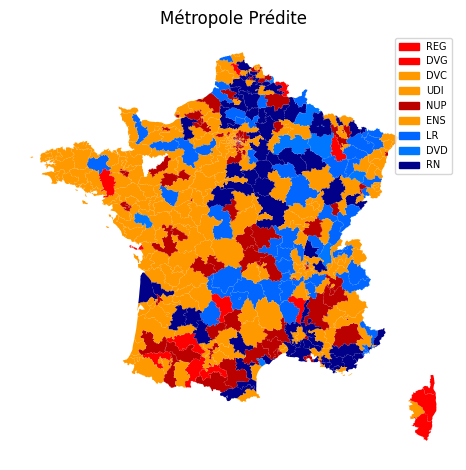

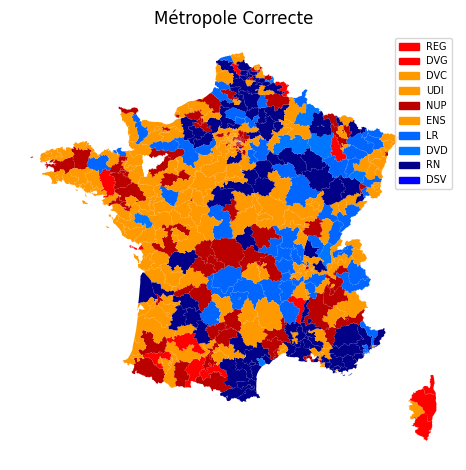

In [40]:
plot_map_france(dataframe_predictions.rename(columns={"id_circ": "id_circ", "predicted_winner": "Winner"}), gdf, "Métropole Prédite")
plot_map_france(dataframe_predictions.rename(columns={"id_circ": "id_circ", "correct_winner": "Winner"}), gdf, "Métropole Correcte")

In [77]:
import itertools
import pandas as pd
import numpy as np

parties_of_interest = ["RN", "FI", "PS", "EELV", "ENS", "LR"]
deltas = np.round(np.arange(0.0, 1.01, 0.1), 2)
coefs = np.round(np.arange(0.0, 1.01, 0.1), 2)

def get_predictions_local(resultats_circ, candidats_circ, delta, bonus_sortant):
    dict_nuance_votes_1 = {}
    dict_nuance_votes_2 = {}
    for i in range(1, 15):
        nuance_candidat = resultats_circ.get(f"Nuance candidat {i}")
        if pd.isna(nuance_candidat):
            continue
        votes_candidat = resultats_circ.get(f"Voix {i}", 0)
        dict_nuance_votes_1[nuance_candidat] = dict_nuance_votes_1.get(nuance_candidat, 0) + votes_candidat

    sortant = ""
    for _, row in candidats_circ.iterrows():
        nuance_candidat = row["Code nuance"]
        if row.get("Sortant") == "OUI":
            sortant = nuance_candidat
        dict_nuance_votes_2[nuance_candidat] = 0

    for key, value in dict_nuance_votes_1.items():
        if key in dict_nuance_votes_2:
            dict_nuance_votes_2[key] += value
        else:
            vector_1 = get_vector(key)
            if vector_1 is None:
                # cannot compute transfers for this nuance
                continue
            total_score = 0.0
            scores = {}
            for key_2 in dict_nuance_votes_2.keys():
                vector_2 = get_vector(key_2)
                # if target vector missing, use large distance penalty
                if vector_2 is None:
                    distance = 10.0
                else:
                    distance = np.linalg.norm(vector_1 - vector_2)
                bonus = bonus_sortant if key_2 == sortant else 0.0
                score = - delta * distance + bonus
                s = np.exp(score)
                scores[key_2] = s
                total_score += s

            if total_score == 0:
                continue
            for key_2, s in scores.items():
                dict_nuance_votes_2[key_2] += value * (s / total_score)

    # if no candidates remain, return None
    if len(dict_nuance_votes_2) == 0:
        return None
    return max(dict_nuance_votes_2, key=dict_nuance_votes_2.get)

def evaluate_grid():
    seat_matrix = pd.DataFrame(index=deltas, columns=coefs, dtype=int)
    accuracy_matrix = pd.DataFrame(index=deltas, columns=coefs, dtype=float)
    # Also keep a dict of DataFrames of seat breakdown for each (delta,coef) if needed
    seat_breakdown = {}

    for d, c in itertools.product(deltas, coefs):
        bonus = d * c
        rows_pred = []
        count_no_candidates = 0
        count_already_elected = 0

        for _, r in resultats_1.iterrows():
            number_canton = str(r["Code circonscription législative"])
            number_canton_v2 = number_canton.zfill(4)
            candidats_2_circ = candidats_2[candidats_2["Code circonscription"] == number_canton]

            if candidats_2_circ.empty:
                count_no_candidates += 1
                continue

            pred = get_predictions_local(r, candidats_2_circ, delta=d, bonus_sortant=bonus)
            results_tour_2_rows = resultats_2[
                ((resultats_2["Code circonscription législative"] == number_canton_v2) |
                 (resultats_2["Code circonscription législative"] == number_canton))
            ]
            if results_tour_2_rows.empty:
                count_already_elected += 1
                continue
            true = get_best_candidate(results_tour_2_rows.iloc[0])
            if pred is None:
                # treat as unresolved — count as incorrect
                rows_pred.append({"id_circ": number_canton_v2, "predicted_winner": None, "correct_winner": true})
            else:
                rows_pred.append({"id_circ": number_canton_v2, "predicted_winner": pred, "correct_winner": true})

        df_pred = pd.DataFrame(rows_pred, columns=["id_circ", "predicted_winner", "correct_winner"])
        # seat counts for predicted winners (only count parties of interest; others ignored)
        seats = {p: 0 for p in parties_of_interest}
        for val in df_pred["predicted_winner"].dropna():
            if val in seats:
                seats[val] += 1
        # accuracy
        if len(df_pred) == 0:
            acc = np.nan
        else:
            acc = (df_pred["predicted_winner"] == df_pred["correct_winner"]).mean() * 100

        seat_matrix.at[d, c] = sum(seats[p] for p in parties_of_interest)  # total counted seats (optional)
        accuracy_matrix.at[d, c] = acc
        # Keep detailed party counts per grid cell
        seat_breakdown[(d, c)] = seats

    # Build per-party matrices
    party_matrices = {}
    for p in parties_of_interest:
        mat = pd.DataFrame(index=deltas, columns=coefs, dtype=int)
        for d, c in itertools.product(deltas, coefs):
            mat.at[d, c] = seat_breakdown[(d, c)].get(p, 0)
        party_matrices[p] = mat

    return party_matrices, accuracy_matrix

party_matrices, accuracy_matrix = evaluate_grid()

# show results (example print)
for p, mat in party_matrices.items():
    print(f"\nSeats matrix for {p}:")
    display(mat)

print("\nAccuracy matrix (% correct):")
display(accuracy_matrix)

# store results to variables for later inspection
seat_matrices_by_party = party_matrices
accuracy_matrix_df = accuracy_matrix


Seats matrix for RN:


,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0,108.0
0.1,87.0,87.0,87.0,87.0,87.0,87.0,87.0,87.0,87.0,87.0,87.0
0.2,73.0,73.0,73.0,73.0,73.0,73.0,73.0,73.0,73.0,73.0,73.0
0.3,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0
0.4,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0
0.5,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0
0.6,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0,43.0
0.7,38.0,38.0,38.0,38.0,38.0,38.0,38.0,38.0,38.0,38.0,38.0
0.8,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0,36.0
0.9,31.0,31.0,31.0,31.0,31.0,31.0,31.0,31.0,31.0,31.0,31.0



Seats matrix for FI:


,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Seats matrix for PS:


...

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.0,186.0,186.0,186.0,186.0,186.0,186.0,186.0,186.0,186.0,186.0,186.0
0.1,230.0,230.0,230.0,230.0,230.0,230.0,230.0,230.0,230.0,230.0,230.0
0.2,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0
0.3,273.0,273.0,273.0,273.0,273.0,273.0,273.0,273.0,273.0,273.0,273.0
0.4,289.0,289.0,289.0,289.0,289.0,289.0,289.0,289.0,289.0,289.0,289.0
0.5,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0,303.0
0.6,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0,312.0
0.7,317.0,317.0,317.0,317.0,317.0,317.0,317.0,317.0,317.0,317.0,317.0
0.8,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0,320.0
0.9,327.0,327.0,327.0,327.0,327.0,327.0,327.0,327.0,327.0,327.0,327.0



Seats matrix for LR:


,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0,40.0
0.1,51.0,51.0,51.0,51.0,51.0,51.0,51.0,51.0,51.0,51.0,51.0
0.2,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0
0.3,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0
0.4,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0,58.0
0.5,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0
0.6,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0
0.7,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0
0.8,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0
0.9,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0,59.0



Accuracy matrix (% correct):


,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
0.0,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281
0.1,86.329588,86.329588,86.329588,86.329588,86.329588,86.329588,86.329588,86.329588,86.329588,86.329588,86.329588
0.2,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386
0.3,86.516854,86.516854,86.516854,86.516854,86.516854,86.516854,86.516854,86.516854,86.516854,86.516854,86.516854
0.4,84.644195,84.644195,84.644195,84.644195,84.644195,84.644195,84.644195,84.644195,84.644195,84.644195,84.644195
0.5,82.584270,82.584270,82.584270,82.584270,82.584270,82.584270,82.584270,82.584270,82.584270,82.584270,82.584270
0.6,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142
0.7,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281,79.775281
0.8,79.213483,79.213483,79.213483,79.213483,79.213483,79.213483,79.213483,79.213483,79.213483,79.213483,79.213483
0.9,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356


Best accuracy: 88.39% achieved at parameters: [(np.float64(0.122), np.float64(0.18)), (np.float64(0.164), np.float64(0.12)), (np.float64(0.165), np.float64(0.11))]

Seats matrix for :


,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,...,9.91,9.92,9.93,9.94,9.95,9.96,9.97,9.98,9.99,10.00
0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.296,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.298,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Accuracy matrix (% correct):


,0.00,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,...,9.91,9.92,9.93,9.94,9.95,9.96,9.97,9.98,9.99,10.00
0.000,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,...,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547,79.962547
0.001,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,...,80.524345,80.524345,80.524345,80.524345,80.524345,80.524345,80.524345,80.524345,80.524345,80.524345
0.002,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,...,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142,81.086142
0.003,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,80.149813,...,81.460674,81.460674,81.460674,81.460674,81.460674,81.460674,81.460674,81.460674,81.460674,81.460674
0.004,80.711610,80.898876,80.898876,80.898876,80.898876,80.898876,80.898876,80.898876,80.898876,80.898876,...,81.647940,81.647940,81.647940,81.647940,81.647940,81.647940,81.647940,81.647940,81.647940,81.647940
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0.295,87.078652,87.078652,87.078652,87.078652,87.078652,87.078652,87.078652,87.078652,87.078652,87.078652,...,77.902622,77.902622,77.902622,77.902622,77.902622,77.902622,77.902622,77.902622,77.902622,77.902622
0.296,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.704120,...,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356
0.297,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.704120,86.891386,...,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356
0.298,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.891386,86.704120,86.891386,...,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356,77.715356


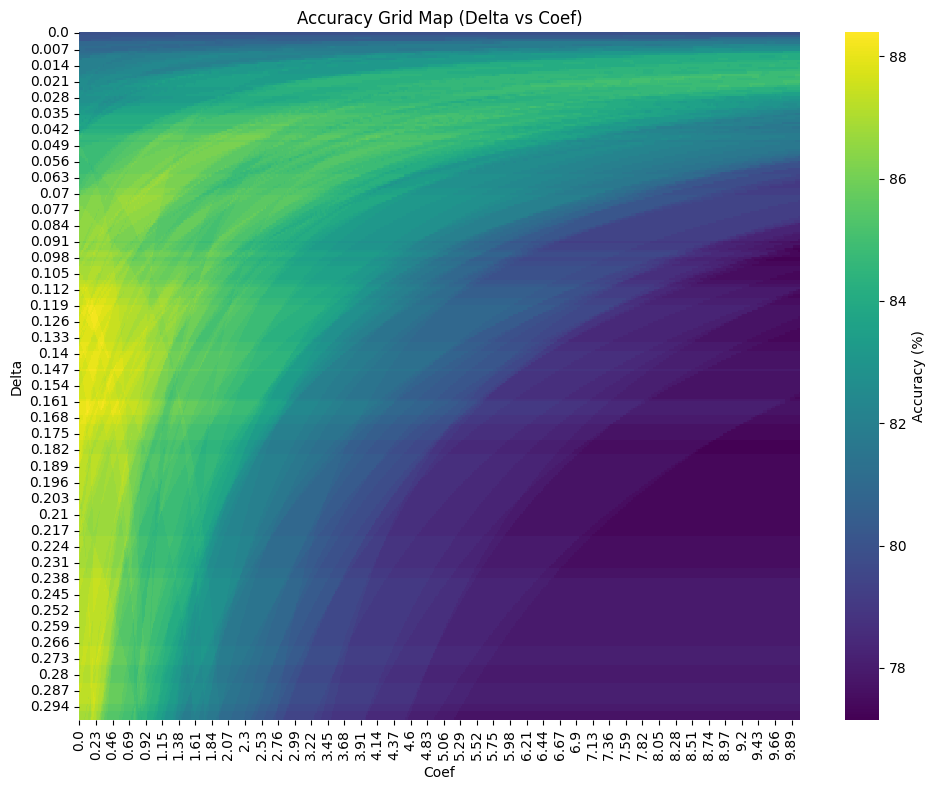

Saved ./outputs/seats_.txt
Saved ./outputs/accuracy_matrix.txt
Saved ./outputs/seat_breakdown_summary.json


In [88]:
# ...existing code...
# Replace the evaluate_grid / helper logic with a faster, parallel and cached version.

import concurrent.futures
import os
import itertools
from functools import partial
import matplotlib.pyplot as plt
import seaborn as sns

parties_of_interest = [""]
delta_start, delta_stop, delta_step = 0.0, 0.3, 0.001
coef_start, coef_stop, coef_step = 0.0, 10.01, 0.01

deltas = np.arange(delta_start, delta_stop, delta_step)
coefs = np.arange(coef_start, coef_stop, coef_step)

def step_decimals(step):
    # choose rounding decimals = -floor(log10(step)) so we don't collapse distinct values
    if step <= 0:
        return 2
    return max(2, int(-np.floor(np.log10(step))))

d_dec = step_decimals(delta_step)
c_dec = step_decimals(coef_step)

deltas = np.round(deltas, d_dec)
coefs = np.round(coefs, c_dec)

if len(np.unique(deltas)) != len(deltas) or len(np.unique(coefs)) != len(coefs):
    raise ValueError("Generated deltas or coefs contain duplicates after rounding — increase precision or change steps.")


# Precompute useful structures to avoid repeated DataFrame lookups
def build_circonscription_infos(resultats_1, candidats_2, resultats_2):
    infos = []
    for _, row in resultats_1.iterrows():
        number_canton = str(row["Code circonscription législative"])
        number_canton_v2 = number_canton.zfill(4)
        candidats_2_circ = candidats_2[candidats_2["Code circonscription"] == number_canton]
        if candidats_2_circ.empty:
            continue
        results_tour_2_rows = resultats_2[
            ((resultats_2["Code circonscription législative"] == number_canton_v2) |
             (resultats_2["Code circonscription législative"] == number_canton))
        ]
        if results_tour_2_rows.empty:
            continue
        # first round tallies
        first_round = {}
        for i in range(1, 23):
            nuance = row.get(f"Nuance candidat {i}")
            if pd.isna(nuance):
                continue
            votes = row.get(f"Voix {i}", 0)
            first_round[nuance] = first_round.get(nuance, 0) + votes
        # second round candidates + sortant
        candidates = []
        sortant = None
        for _, r2 in candidats_2_circ.iterrows():
            nuance2 = r2["Code nuance"]
            candidates.append(nuance2)
            if r2.get("Sortant") == "Oui":
                sortant = nuance2
        true_winner = get_best_candidate(results_tour_2_rows.iloc[0])
        infos.append({
            "id": number_canton_v2,
            "first_round": first_round,
            "candidates": candidates,
            "sortant": sortant,
            "true_winner": true_winner
        })
    return infos

# cache vectors for nuances (uses existing MAPPING_PARTI_CATEGORIES and columns_to_keep)
def build_vector_cache(nuances):
    cache = {}
    for n in nuances:
        try:
            party = MAPPING_PARTI_CATEGORIES.get(n, n)
            vecs = political_views[political_views["party"] == party][columns_to_keep].values
            cache[n] = vecs[0] if len(vecs) else None
        except Exception:
            cache[n] = None
    return cache

# precompute pairwise distances between nuances (use large distance if any vector missing)
def build_distance_lookup(nuances, vec_cache, missing_distance=10.0):
    dist = {}
    nu_list = list(nuances)
    for a in nu_list:
        for b in nu_list:
            if (a, b) in dist:
                continue
            va = vec_cache.get(a)
            vb = vec_cache.get(b)
            if va is None or vb is None:
                d = missing_distance
            else:
                d = float(np.linalg.norm(va - vb))
            dist[(a, b)] = d
            dist[(b, a)] = d
    return dist

# faster local prediction using precomputed distances and no DataFrame lookups
def predict_for_circ_fast(first_round, candidates, sortant, delta, bonus_sortant, distance_lookup):
    dict_dst = {c: 0.0 for c in candidates}
    for nuance, votes in first_round.items():
        if nuance in dict_dst:
            dict_dst[nuance] += votes
            continue
        # distribute votes to candidates
        scores = {}
        total = 0.0
        for cand in candidates:
            d = distance_lookup.get((nuance, cand), 10.0)
            bonus = bonus_sortant if cand == sortant else 0.0
            s = np.exp(-delta * d + bonus)
            scores[cand] = s
            total += s
        if total == 0:
            continue
        for cand, s in scores.items():
            dict_dst[cand] += votes * (s / total)
    if len(dict_dst) == 0:
        return None
    return max(dict_dst, key=dict_dst.get)

# Worker for one grid cell (d, c)
def process_grid_cell(d, c, circ_infos, parties_of_interest, distance_lookup):
    bonus = d * c
    rows_pred = []
    for info in circ_infos:
        pred = predict_for_circ_fast(info["first_round"], info["candidates"], info["sortant"], d, bonus, distance_lookup)
        rows_pred.append({"id_circ": info["id"], "predicted_winner": pred, "correct_winner": info["true_winner"]})
    df_pred = pd.DataFrame(rows_pred, columns=["id_circ", "predicted_winner", "correct_winner"])
    seats = {p: 0 for p in parties_of_interest}
    for val in df_pred["predicted_winner"].dropna():
        if val in seats:
            seats[val] += 1
    acc = np.nan if len(df_pred) == 0 else (df_pred["predicted_winner"] == df_pred["correct_winner"]).mean() * 100
    return (d, c, seats, acc)

# Main optimized evaluate_grid using multiprocessing (process pool)
def evaluate_grid_optimized(resultats_1, candidats_2, resultats_2, parties_of_interest, deltas, coefs, n_workers=None):
    # build circ infos once
    circ_infos = build_circonscription_infos(resultats_1, candidats_2, resultats_2)
    # gather all nuances to compute vector cache and distances
    all_nuances = set()
    for info in circ_infos:
        all_nuances.update(info["first_round"].keys())
        all_nuances.update(info["candidates"])
        if info["sortant"]:
            all_nuances.add(info["sortant"])
        all_nuances.add(info["true_winner"])
    vec_cache = build_vector_cache(all_nuances)
    distance_lookup = build_distance_lookup(all_nuances, vec_cache)

    # parallel execution across grid cells
    results = []
    if n_workers is None:
        n_workers = max(1, (os.cpu_count() or 1) - 1)
    with concurrent.futures.ProcessPoolExecutor(max_workers=n_workers) as exe:
        futures = []
        for d, c in itertools.product(deltas, coefs):
            futures.append(exe.submit(process_grid_cell, d, c, circ_infos, parties_of_interest, distance_lookup))
        for fut in concurrent.futures.as_completed(futures):
            results.append(fut.result())

    # assemble outputs
    seat_breakdown = {}
    accuracy_matrix = pd.DataFrame(index=deltas, columns=coefs, dtype=float)
    for d, c, seats, acc in results:
        seat_breakdown[(d, c)] = seats
        accuracy_matrix.at[d, c] = acc

    party_matrices = {}
    for p in parties_of_interest:
        mat = pd.DataFrame(index=deltas, columns=coefs, dtype=int)
        for d, c in itertools.product(deltas, coefs):
            mat.at[d, c] = seat_breakdown[(d, c)].get(p, 0)
        party_matrices[p] = mat

    return party_matrices, accuracy_matrix

# Use optimized evaluator
party_matrices, accuracy_matrix = evaluate_grid_optimized(resultats_1, candidats_2, resultats_2,
                                                          parties_of_interest, deltas, coefs)

# store results
seat_matrices_by_party = party_matrices
accuracy_matrix_df = accuracy_matrix

# print the best accuracy and corresponding parameters
best_acc = accuracy_matrix_df.max().max()
best_params = [(d, c) for d in deltas for c in coefs if accuracy_matrix_df.at[d, c] == best_acc]
print(f"Best accuracy: {best_acc:.2f}% achieved at parameters: {best_params}")
# show results
for p, mat in party_matrices.items():
    print(f"\nSeats matrix for {p}:")
    display(mat)
print("\nAccuracy matrix (% correct):")
display(accuracy_matrix)
# --- New: save matrices to ./outputs as text files ---
os.makedirs("./output", exist_ok=True)
os.makedirs("./outputs", exist_ok=True)

# Generate and save heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(accuracy_matrix_df, cmap="viridis", cbar_kws={'label': 'Accuracy (%)'})
plt.title("Accuracy Grid Map (Delta vs Coef)")
plt.xlabel("Coef")
plt.ylabel("Delta")
plt.tight_layout()
plt.savefig("./output/grid_map_2017.png")
plt.show()

# save each party matrix as a tab-separated text file
for party, mat in seat_matrices_by_party.items():
    path = f"./outputs/seats_{party}.txt"
    mat.to_csv(path, sep="\t", index=True, header=True)
    print(f"Saved {path}")

# save accuracy matrix
acc_path = "./outputs/accuracy_matrix.txt"
accuracy_matrix_df.to_csv(acc_path, sep="\t", index=True, header=True)
print(f"Saved {acc_path}")

# also save a combined summary (JSON) with per-cell seat breakdown if needed
import json
summary_path = "./outputs/seat_breakdown_summary.json"
seat_breakdown = {}
for d in deltas:
    for c in coefs:
        key = f"{d}_{c}"
        seat_breakdown[key] = {p: int(seat_matrices_by_party[p].at[d, c]) for p in parties_of_interest}
with open(summary_path, "w") as fh:
    json.dump({"deltas": deltas.tolist(), "coefs": coefs.tolist(), "seat_breakdown": seat_breakdown}, fh)
print(f"Saved {summary_path}")